# CSI Based WiFi Setting


### By Seth Kantz and Matthew Delafield

The goal for this project will be to detect motion in a room given CSI data from a raspberry pi 4b.  Structure shown here is for use with CSI Dataset available via IEEE Dataport https://ieee-dataport.org/documents/csi-dataset-wifi-based-human-detection .  Place in repo and rename 'CSV Files' to 'CSV_Files' for best use.

This data is captured from a 20MHz channel via Nexmon tool, see here for setup and use. https://github.com/seemoo-lab/nexmon_csi?tab=readme-ov-file#getting-started

The imaginary data from each channel is used and fed into the CNN for better understanding, the neural network will see how these values change over time vs a known "no motion" and a known "motion" to classify as one of those two categories


### Imports
Import necessary files, note that cuda driver failures are expected if running on a laptop or a machine without GPU.  The processing should behave just find and these issues can be ignored.  If other errors occur you need to ensure that imports are installed correctly via pip

In [1]:
from pathlib import Path
import numpy as np
import re
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

import math
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

###

2026-05-05 08:31:34.955924: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 08:31:34.957447: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 08:31:35.008129: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 08:31:36.559452: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

### Set Variables / Paths

Set up high level logic for subcarriers, expected file / folder layout for data to be read in.

In [2]:
#
# sets path used for training the data, room 4 for basis now
#ROOT = Path("data/hf_dataset/pcap_csvs/split_csv")

ROOT = Path("data/hf_dataset_mod/pcap_csvs/split_csv")

# key=testname, val= (static_folder, dynamic_folder)
test_dict = {
    #"RoomS_LocA_ch011_20MHz": ("20_idle_ch11", "20_walking_ch11"),
    "RoomS_LocA_ch011_20MHz": ("20_idle", "20_walking"),
    "RoomS_LocA_ch157_40MHz": ("40_idle", "40_walking"),
    "RoomS_LocA_ch157_80MHz": ("80_idle", "80_walking"),
}

'''
    "RoomS_LocB_ch157_40MHz": ("40_idle_blocked", "40_walking_blocked"),
    "RoomS_LocB_ch157_80MHz": ("80_idle_blocked", "80_walking_blocked"),
    # matt
    "RoomM_Loc5_ch011_20MHz": ("20_5t_static_idle_roomM", "20_5ft_motion_walking_roomM"),
    "RoomM_Loc5_ch157_40MHz": ("40_5ft_static_idle_roomM", "40_5ft_motion_walking_roomM"),
    "RoomM_Loc5_ch157_80MHz": ("80_5ft_static_idle_roomM", "80_5ft_motion_walking_roomM"),
    
    "RoomM_Loc10_ch011_20MHz": ("20_10ft_static_idle_roomM", "20_10ft_motion_walking_roomM"),
    "RoomM_Loc10_ch157_40MHz": ("40_10ft_static_idle_roomM", "40_10ft_motion_walking_roomM"),
    "RoomM_Loc10_ch157_80MHz": ("80_10ft_static_idle_roomM", "80_10ft_motion_walking_roomM"),
}
'''

STATIC_MAG   = ROOT / "40_idle"
DYNAMIC_MAG  = ROOT / "40_walking"

#STATIC_MAG   = ROOT / "Static_noperson_channel_11_20mhz" / "csi_magnitude_data"
#DYNAMIC_MAG  = ROOT / "Dynamic_1_person_ch11_20mhz"      / "csi_magnitude_data"

STATIC_CPLX  = ROOT / "Static_noperson_channel_11_20mhz" / "csi_complex_data"
DYNAMIC_CPLX = ROOT / "Dynamic_1_person_ch11_20mhz"      / "csi_complex_data"

# sets number of subcarriers used (49 for 20MHz)
SUBCARRIERS_20MHz = 64 #49
SUBCARRIERS_40MHz = 128
SUBCARRIERS_80MHz = 256


# sets number of rows to be fed into neural net
L = 1024  

base = ROOT

# using dict for now, could switch to class based, but dict is easier to preserve current format
model_dict = {}
history_dict = {}
subcarrier_dict = {}
train_pathy_dict = {}
val_pathy_dict = {}
test_pathy_dict = {}
gen_trainvaltest_dict = {}

### Helper Functions
Functions that make life easier later on for reading data, separating files, loading, etc

In [3]:

def gather_paths(static_path, dynamic_path):
    ''' Return paths and labels for static + dynamic files'''
    static_files  = sorted(static_path.glob("*.csv"))
    dynamic_files = sorted(dynamic_path.glob("*.csv"))

    paths = static_files + dynamic_files
    labels = np.array([0]*len(static_files) + [1]*len(dynamic_files), dtype=np.int32)
    return paths, labels

def load_mag_csv(path, num_subcarriers, L=L):
    # function to load in the magnitude data 
    
    df = pd.read_csv(path)
    # (T, 49)
    X = df.to_numpy(dtype=np.float32)          
    X = np.log1p(np.abs(X))                  
    T, S = X.shape

    # sanity check here to make sure we ahve correct subcarrier len
    assert S == num_subcarriers, f"Expected {num_subcarriers} cols, got {S}"

    if T >= L:
        start = np.random.randint(0, T - L + 1)
        X = X[start:start+L]
    else:
        X = np.pad(X, ((0, L - T), (0, 0)), mode="edge")
        
    # normalize data read in
    mean = np.mean(X, axis=0, keepdims=True)
    std = np.std(X, axis=0, keepdims=True)
    
    
    X_out = (X - mean) / (std + 1e-8)

    return X_out

def recording_id(p: Path):
    # grabs naming for csi_YYYYMMDD_HHMMSS
    m = re.search(r"(csi_\d{8}_\d{6})", p.name)
    return m.group(1) if m else p.stem
    
def batch_generator(paths, labels, num_subcarriers, batch_size, class_weight=None):
    while True:
        idx = np.random.choice(len(paths), size=batch_size, replace=True)

        Xb = np.stack([
            load_mag_csv(paths[i], num_subcarriers) for i in idx
        ])

        yb = labels[idx].astype(np.float32)

        if class_weight is not None:
            sample_weight = np.array(
                [class_weight[int(y)] for y in yb],
                dtype=np.float32
            )
            yield Xb, yb, sample_weight
        else:
            yield Xb, yb
            
class CSIDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, paths, labels, num_subcarriers, batch_size, class_weight=None, L=1024):
        self.paths = paths
        self.labels = labels
        self.num_subcarriers = num_subcarriers
        self.batch_size = batch_size
        self.class_weight = class_weight
        self.L = L
        # Create an index array to shuffle
        self.indices = np.arange(len(self.paths))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.paths) / self.batch_size)

    def __getitem__(self, index):
        # Gather batches using the shuffled indices
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        
        Xb = np.stack([
            load_mag_csv(self.paths[i], self.num_subcarriers, self.L) for i in batch_indices
        ])
        yb = self.labels[batch_indices].astype(np.float32)

        if self.class_weight is not None:
            sample_weight = np.array([self.class_weight[int(y)] for y in yb], dtype=np.float32)
            return Xb, yb, sample_weight
        
        return Xb, yb

    def on_epoch_end(self):
        # Shuffle indices at the end of each epoch
        np.random.shuffle(self.indices)

### Read in Data


This step will read in the training data and begin to split filepaths into the necessary groups using groupshufflesplit.  Two calls are needed to separate into three distinct buckets.

Currently using 60/25/15 train/val/test split

In [4]:

test_key = "RoomS_LocA_ch011_20MHz"

def update_subcarriers_dict(chan_key):
    if "20MHz" in chan_key:
        subcarriers = SUBCARRIERS_20MHz
    elif "40MHz" in chan_key:
        subcarriers = SUBCARRIERS_40MHz
    elif "80MHz" in chan_key:
        subcarriers = SUBCARRIERS_80MHz
    else:
        print("ERR INVALID SUBCARRIERS")

    subcarrier_dict[chan_key] = subcarriers

def update_path_dict(chan_key):
    static_folder, dynamic_folder = test_dict[chan_key]
    static_files = ROOT / static_folder
    dynamic_files = ROOT / dynamic_folder

    paths, labels = gather_paths(static_files,dynamic_files)
    paths = np.array(paths)
    groups = np.array([recording_id(p) for p in paths])
    '''
    # Separate 60% for training, 40% for test/val
    gss = GroupShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
    trainval_idx, test_idx = next(gss.split(paths, labels, groups=groups))

    # Separate 15% (0.375*0.4) for training, 25% for validation
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.375, random_state=43)
    '''
    # 85% train+val, 15% test
    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
    trainval_idx, test_idx = next(gss.split(paths, labels, groups=groups))

    # From remaining 85%, take 25/85 = 0.294 as validation
    # Final split is approximately 60% train, 25% val, 15% test
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.294, random_state=43)
    train_sub_idx, val_sub_idx = next(
        gss2.split(
            paths[trainval_idx],
            labels[trainval_idx],
            groups=groups[trainval_idx]
        )
    )

    

    # Map subset indices back to original dataset indices
    train_idx = trainval_idx[train_sub_idx]
    val_idx   = trainval_idx[val_sub_idx]

    train_paths = paths[train_idx]
    val_paths   = paths[val_idx]
    test_paths  = paths[test_idx]

    train_y = labels[train_idx]
    val_y   = labels[val_idx]
    test_y  = labels[test_idx]
    print("Train labels:", np.bincount(train_y.astype(int)))
    print("Val labels:", np.bincount(val_y.astype(int)))
    print("Test labels:", np.bincount(test_y.astype(int)))
    print(len(train_paths))
    print(len(val_paths))
    print(len(test_paths))
    print("Train ∩ Val:", len(set(train_paths) & set(val_paths)))
    print("Train ∩ Test:", len(set(train_paths) & set(test_paths)))
    print("Val ∩ Test:", len(set(val_paths) & set(test_paths)))
    print("Unique groups total:", len(set(groups)))
    print("Train groups:", len(set(groups[train_idx])))
    print("Val groups:", len(set(groups[val_idx])))
    print("Test groups:", len(set(groups[test_idx])))
    print("Group overlap train/val:", set(groups[train_idx]) & set(groups[val_idx]))
    train_pathy_dict[chan_key] = (train_paths, train_y)
    val_pathy_dict[chan_key] = (val_paths, val_y)
    test_pathy_dict[chan_key] = (test_paths, test_y)

### Set Train / Test / Validation Split

Uses above filepaths and breaks up dataset read in so we can properly validate neural net

In [5]:
#

batch_size = 8
def update_gen(chan_key):
    # get from dict
    train_paths, train_y = train_pathy_dict[chan_key]
    val_paths, val_y = val_pathy_dict[chan_key]
    test_paths, test_y = test_pathy_dict[chan_key]
    subcarriers = subcarrier_dict[chan_key]

    
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=train_y.astype(int)
    )

    class_weight = {
        0: float(weights[0]),
        1: float(weights[1]),
    }

    print("Class weights:", class_weight)


    train_gen = CSIDataGenerator(
        paths=train_paths,       
        labels=train_y,     
        num_subcarriers=subcarriers, 
        batch_size=8,            
        class_weight=class_weight, 
        L=1024
    )

    
    val_gen = CSIDataGenerator(
        paths=val_paths,         
        labels=val_y,       
        num_subcarriers=subcarriers, 
        batch_size=8,
        L=1024
    )
    test_gen = CSIDataGenerator(
        paths=test_paths,         
        labels=test_y,       
        num_subcarriers=subcarriers, 
        batch_size=8,
        L=1024
    )
    
    # update train / val / test dict
    gen_trainvaltest_dict[chan_key] = (train_gen, val_gen, test_gen)



### Configure 2D Convolutional neural net

Basic structure for neural net and print.  Chosen based on what we learned from neural networks course.  @todo tweak as test results come in, verify this behaving as expected.

CUDA error here is expected bc of above note.


In [6]:

def update_model(chan_key):
    subcarriers = subcarrier_dict[chan_key]
    print(f"subcarrier={subcarriers}")
    
    reg = tf.keras.regularizers.l2(1e-4)
    #inp = layers.Input(shape=(L, subcarriers, 2))
    inp = layers.Input(shape=(L, subcarriers))


    x = layers.Conv1D(8, kernel_size=9, padding="same", use_bias=False, kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=4)(x)

    
    x = layers.Conv1D(16, kernel_size=5, padding="same", use_bias=False, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=4)(x)

    x = layers.GlobalMaxPooling1D()(x)
    
    x = layers.Dropout(0.6)(x)

    
    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    THRESHOLD = 0.475

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=THRESHOLD),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
            tf.keras.metrics.Precision(name="precision", thresholds=THRESHOLD),
            tf.keras.metrics.Recall(name="recall", thresholds=THRESHOLD),
        ]
    )
    
    model.summary()
    model_dict[chan_key] = model

### Train Model

Train data, note that this can take some time to run, but early stopping should prevent overfitting / overly long tests.

In [7]:
#

def train_model(chan_key):
    # get from dict
    (train_gen, val_gen, test_gen) = gen_trainvaltest_dict[chan_key]
    train_paths, train_y = train_pathy_dict[chan_key]
    val_paths, val_y = val_pathy_dict[chan_key]
    model = model_dict[chan_key]
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", patience=15, mode="max", restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", factor=0.5, patience=3, mode="max", min_lr=1e-6),
    ]
    # train
    history = model.fit(
        train_gen,
        #steps_per_epoch=max(1, math.ceil(len(train_paths) / batch_size)),
        validation_data=val_gen,
        #validation_steps=max(1, math.ceil(len(val_paths) / batch_size)),
        epochs=60,
        callbacks=callbacks
    )

    history_dict[chan_key] = history

### Evaluate Model

Basic evaluation printed here.

In [8]:
#

def eval_model(chan_key):
    _, _, test_gen = gen_trainvaltest_dict[chan_key]
    test_paths, _ = test_pathy_dict[chan_key]    
    model = model_dict[chan_key]
    
    steps = int(np.ceil(len(test_paths) / batch_size))

    print(model.evaluate(test_gen, steps=steps))


'\ndef eval_model(chan_key):\n    test_paths, test_y = test_pathy_dict[chan_key]\n    model = model_dict[chan_key]\n\n    X_test = np.stack([\n        load_mag_csv(p, subcarrier_dict[chan_key]) for p in test_paths\n    ])\n\n    y_prob = model.predict(X_test).ravel()\n\n    print("Prediction min/max:", y_prob.min(), y_prob.max())\n    print("AUC:", roc_auc_score(test_y, y_prob))\n\n    for t in np.linspace(0.1, 0.9, 9):\n        y_pred = (y_prob >= t).astype(int)\n\n        print(\n            f"threshold={t:.1f}",\n            "acc=", accuracy_score(test_y, y_pred),\n            "precision=", precision_score(test_y, y_pred, zero_division=0),\n            "recall=", recall_score(test_y, y_pred, zero_division=0),\n            "f1=", f1_score(test_y, y_pred, zero_division=0),\n        )\n'

### Calculate errors / performance


### Graph Data

Helper graphs to better understand how it is behaving.

will add more error / performance sanity checks here later if needed as data comes in.

In [9]:

def graph_trainval_loss(chan_key):
    history = history_dict[chan_key]
    
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(chan_key + 'Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [10]:
def graph_trainval_auc(chan_key):
    history = history_dict[chan_key]

    plt.figure(figsize=(8,5))
    plt.plot(history.history['auc'], label='Train AUC')
    plt.plot(history.history['val_auc'], label='Validation AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.title(chan_key + 'Training and Validation AUC')
    plt.legend()
    plt.grid(True)
    plt.show()

In [11]:
for key, path in test_dict.items():
    print("--")
    print(key)
    update_subcarriers_dict(key)
    update_path_dict(key)
    update_gen(key)
    update_model(key)
    train_model(key)

--
RoomS_LocA_ch011_20MHz
Train labels: [31 21]
Val labels: [15  8]
Test labels: [11  3]
52
23
14
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0
Unique groups total: 89
Train groups: 52
Val groups: 23
Test groups: 14
Group overlap train/val: set()
Class weights: {0: 0.8387096774193549, 1: 1.2380952380952381}
subcarrier=64


2026-05-05 08:31:37.233196: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1024, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1024, 8)        │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024, 8)        │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 256, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 256, 16)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 16)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,361 (20.94 KB)

...

 Non-trainable params: 48 (192.00 B)

/home/seth/tf-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 984ms/step - accuracy: 0.4928 - auc: 0.5187 - loss: 2.8865 - pr_auc: 0.5818 - precision: 0.5414 - recall: 0.5894

/home/seth/tf-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


105/105 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.5333 - auc: 0.5549 - loss: 2.7460 - pr_auc: 0.5854 - precision: 0.5605 - recall: 0.6322 - val_accuracy: 0.9086 - val_auc: 0.9855 - val_loss: 0.2466 - val_pr_auc: 0.9857 - val_precision: 0.8608 - val_recall: 0.9709 - learning_rate: 1.0000e-04
Epoch 2/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6393 - auc: 0.6712 - loss: 1.8117 - pr_auc: 0.6750 - precision: 0.6603 - recall: 0.6850 - val_accuracy: 0.9514 - val_auc: 0.9987 - val_loss: 0.1173 - val_pr_auc: 0.9987 - val_precision: 0.9101 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.7024 - auc: 0.7779 - loss: 1.1462 - pr_auc: 0.7906 - precision: 0.7277 - recall: 0.7181 - val_accuracy: 0.9486 - val_auc: 0.9986 - val_loss: 0.0956 - val_pr_auc: 0.9987 - val_precision: 0.9096 - val_recall: 0.9942 - learning_rate: 1.0000e-04
Epoch 4/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7702 - auc: 0.860

In [12]:
for key, path in test_dict.items():
    print("--")
    print(key)
    eval_model(key)


--
RoomS_LocA_ch011_20MHz


/home/seth/tf-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7857 - auc: 0.3636 - loss: 0.8607 - pr_auc: 0.1765 - precision: 0.0000e+00 - recall: 0.0000e+00
[0.8607233762741089, 0.7857142686843872, 0.3636363744735718, 0.1765316128730774, 0.0, 0.0]
--
RoomS_LocA_ch157_40MHz


/home/seth/tf-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 479ms/step - accuracy: 0.9414 - auc: 0.9974 - loss: 0.1406 - pr_auc: 0.9977 - precision: 1.0000 - recall: 0.8855
[0.14062181115150452, 0.94140625, 0.9974350929260254, 0.9977369904518127, 1.0, 0.885496199131012]
--
RoomS_LocA_ch157_80MHz


/home/seth/tf-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 938ms/step - accuracy: 0.9858 - auc: 0.9997 - loss: 0.0331 - pr_auc: 0.9997 - precision: 0.9725 - recall: 1.0000
[0.03314003720879555, 0.9857819676399231, 0.9997304677963257, 0.9997351169586182, 0.9724770784378052, 1.0]


--
RoomS_LocA_ch011_20MHz


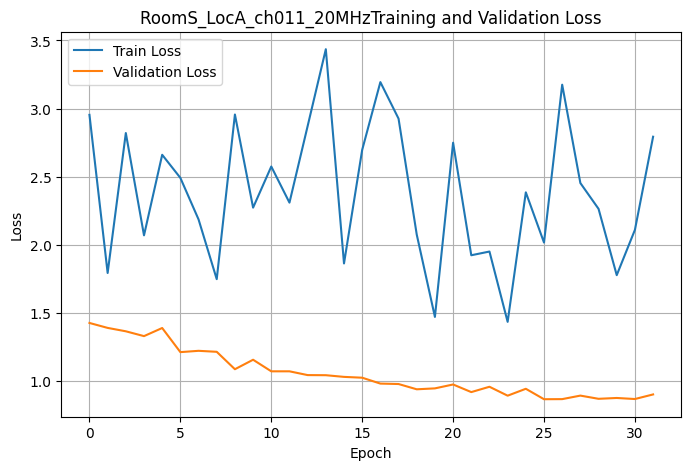

--
RoomS_LocA_ch157_40MHz


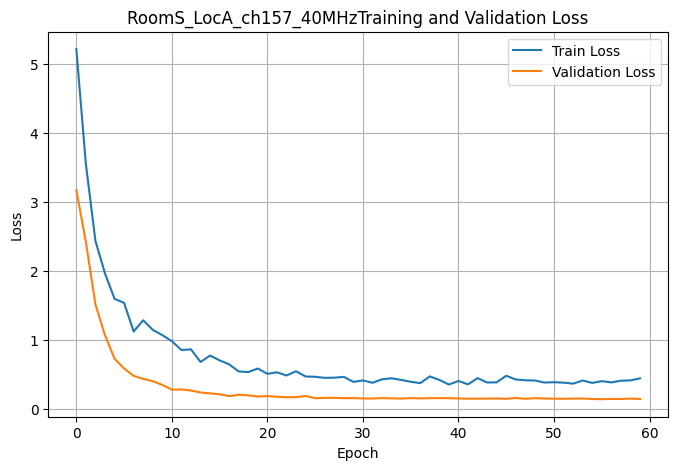

--
RoomS_LocA_ch157_80MHz


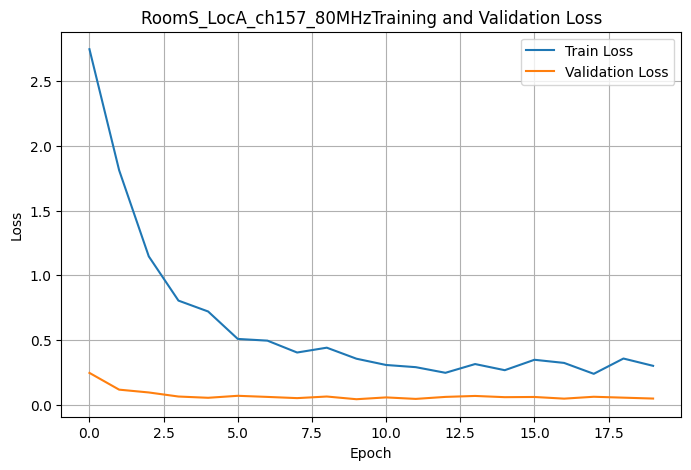

In [13]:
for key, path in test_dict.items():
    print("--")
    print(key)
    graph_trainval_loss(key)


--
RoomS_LocA_ch011_20MHz


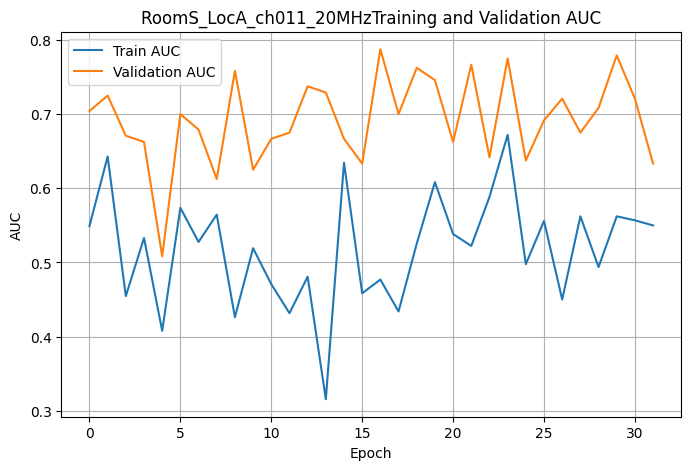

--
RoomS_LocA_ch157_40MHz


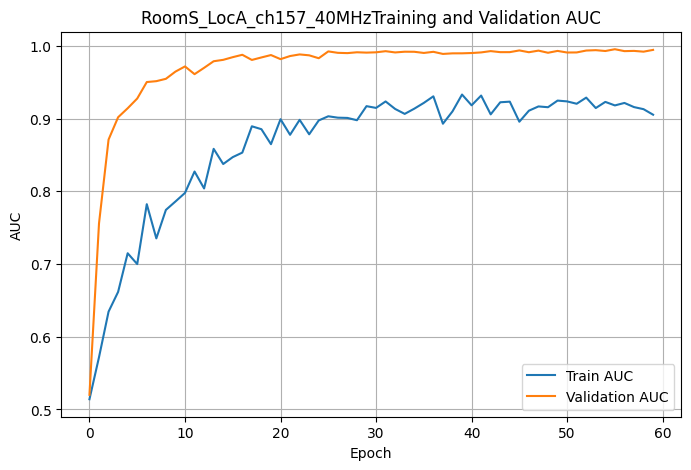

--
RoomS_LocA_ch157_80MHz


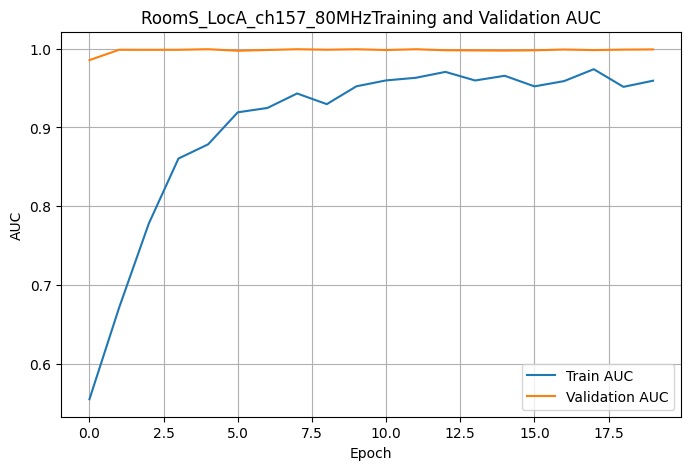

In [14]:
for key, path in test_dict.items():
    print("--")
    print(key)
    graph_trainval_auc(key)

In [16]:
for key, path in test_dict.items():
    print("--")
    print(key)
    model = model_dict[key]
    model.save(f'{key}_2.keras')

--
RoomS_LocA_ch011_20MHz
--
RoomS_LocA_ch157_40MHz
--
RoomS_LocA_ch157_80MHz
